# Eksperimen 4: Uji Coba Bulk Processing dan DataLoader
Notebook ini menguji dua komponen pipeline data secara end-to-end:
1. `build_dataset.py` — memproses banyak video sekaligus dari folder `raw` dan menghasilkan file manifest CSV.
2. `WeightTrainingDataset` + `DataLoader` — memuat tensor dari disk dan menyiapkan batch untuk pelatihan model.

**Output yang diverifikasi:**
* `data/processed/tensors/*.npy` — tensor individual (64, 33, 3)
* `data/processed/dataset_manifest.csv` — manifest {file_path, label}
* Shape satu batch: `batch_data.shape = (16, 64, 33, 3)`, `batch_labels.shape = (16,)`

### 1. Import Library & Konfigurasi

In [1]:
# ============================================================
# Import library dan daftarkan src/ ke sys.path
# ============================================================
import sys
import os
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Tambahkan direktori src/ ke Python path
sys.path.insert(0, os.path.abspath("../src"))

from data.build_dataset import build_dataset, CLASS_LABEL_MAP
from data.dataset import WeightTrainingDataset, create_dataloaders

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Import berhasil.")
print(f"PyTorch versi : {torch.version}")
print(f"Device aktif  : {DEVICE}")

Import berhasil.
PyTorch versi : <module 'torch.version' from 'c:\\Users\\Administrator\\anaconda3\\envs\\attentiveskel\\lib\\site-packages\\torch\\version.py'>
Device aktif  : cuda


### 2. Definisi Path

In [2]:
# ============================================================
# Definisi path direktori root
# ============================================================
RAW_ROOT = Path("../data/raw")
PROCESSED_ROOT = Path("../data/processed")
MANIFEST_PATH = PROCESSED_ROOT / "dataset_manifest.csv"
TENSOR_DIR = PROCESSED_ROOT / "tensors"

print(f"Raw root      : {RAW_ROOT.resolve()}")
print(f"Processed root: {PROCESSED_ROOT.resolve()}")
print(f"Manifest path : {MANIFEST_PATH.resolve()}")

# Periksa struktur folder data/raw/
print("\nStruktur folder data/raw/ yang ditemukan:")
if RAW_ROOT.exists():
    for exercise_dir in sorted(RAW_ROOT.iterdir()):
        if exercise_dir.is_dir():
            for class_dir in sorted(exercise_dir.iterdir()):
                if class_dir.is_dir():
                    n_videos = len(list(class_dir.glob("*.mp4")))
                    label = CLASS_LABEL_MAP.get(class_dir.name, "?")
                    print(f"  {exercise_dir.name}/{class_dir.name}/ → {n_videos} video (label={label})")
else:
    print(f" [PERINGATAN] Direktori {RAW_ROOT} belum ada.")
    print("  Buat struktur folder: data/raw/<NamaLatihan>/<Benar|Salah>/video.mp4")

Raw root      : D:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC\data\raw
Processed root: D:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC\data\processed
Manifest path : D:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC\data\processed\dataset_manifest.csv

Struktur folder data/raw/ yang ditemukan:
  Deadlift/Benar/ → 2 video (label=0)
  Deadlift/Salah/ → 2 video (label=1)


### 3. Jalankan Bulk Processing (build_dataset)
**Catatan:** Cell ini akan memproses semua video yang ada di `raw`. 
Jika `dataset_manifest.csv` sudah ada dan video belum berubah, tensor yang sudah ada akan di-skip secara otomatis (`overwrite=False`).
Ubah `overwrite=True` untuk memproses ulang semua video dari awal.

In [3]:
# ============================================================
# Proses semua video dan buat manifest CSV.
# Set overwrite=True untuk memproses ulang video yang sudah ada.
# ============================================================
manifest_df = build_dataset(
    raw_root=RAW_ROOT,
    processed_root=PROCESSED_ROOT,
    overwrite=False,
)

print(f"\nManifest CSV hasil build_dataset:")
print(manifest_df.head(10).to_string(index=False))
print(f"\nTotal baris : {len(manifest_df)}")
print(f"Kolom       : {list(manifest_df.columns)}")

[INFO] Ditemukan 1 jenis latihan: ['Deadlift']
[INFO] 
[Deadlift/Benar] Memproses 2 video (label=0)...
[INFO]   [001/002] Di-skip (sudah ada): Deadlift_Benar_001.npy
[INFO]   [002/002] Di-skip (sudah ada): Deadlift_Benar_002.npy
[INFO] 
[Deadlift/Salah] Memproses 2 video (label=1)...
[INFO]   [001/002] Di-skip (sudah ada): Deadlift_Salah_001.npy
[INFO]   [002/002] Di-skip (sudah ada): Deadlift_Salah_002.npy
[INFO] 
[INFO] Dataset manifest disimpan ke : ..\data\processed\dataset_manifest.csv
[INFO] Total sampel                 : 4
[INFO]   Kelas 0 (Benar)           : 2 sampel
[INFO]   Kelas 1 (Salah)           : 2 sampel
[INFO] ============================================================



Manifest CSV hasil build_dataset:
                                       file_path  label
..\data\processed\tensors\Deadlift_Benar_002.npy      0
..\data\processed\tensors\Deadlift_Salah_002.npy      1
..\data\processed\tensors\Deadlift_Benar_001.npy      0
..\data\processed\tensors\Deadlift_Salah_001.npy      1

Total baris : 4
Kolom       : ['file_path', 'label']


### 4. Inspeksi Manifest CSV

In [4]:
# ============================================================
# Muat ulang manifest dari disk dan tampilkan statistiknya.
# ============================================================
if not MANIFEST_PATH.exists():
    print("[PERINGATAN] Manifest CSV belum ada. Jalankan Cell di atas terlebih dahulu.")
else:
    df = pd.read_csv(MANIFEST_PATH)
    print(f"Manifest dimuat dari: {MANIFEST_PATH}")
    print(f"Shape               : {df.shape}  (baris=sampel, kolom={list(df.columns)})")
    print()
    print("Distribusi label:")
    
    label_map_inv = {0: "Benar", 1: "Salah"}
    for label_val, label_name in label_map_inv.items():
        count = (df["label"] == label_val).sum()
        print(f"  Label {label_val} ({label_name}) : {count} sampel ({count/len(df)*100:.1f}%)")

    print()
    print("Contoh 5 baris pertama:")
    print(df.head().to_string(index=False))

Manifest dimuat dari: ..\data\processed\dataset_manifest.csv
Shape               : (4, 2)  (baris=sampel, kolom=['file_path', 'label'])

Distribusi label:
  Label 0 (Benar) : 2 sampel (50.0%)
  Label 1 (Salah) : 2 sampel (50.0%)

Contoh 5 baris pertama:
                                       file_path  label
..\data\processed\tensors\Deadlift_Benar_002.npy      0
..\data\processed\tensors\Deadlift_Salah_002.npy      1
..\data\processed\tensors\Deadlift_Benar_001.npy      0
..\data\processed\tensors\Deadlift_Salah_001.npy      1


### 5. Inisialisasi WeightTrainingDataset

In [5]:
# ============================================================
# Buat instance WeightTrainingDataset dari manifest CSV.
# ============================================================
if not MANIFEST_PATH.exists():
    print("[PERINGATAN] Manifest CSV belum ada. Jalankan Cell build_dataset terlebih dahulu.")
else:
    dataset = WeightTrainingDataset(csv_file=MANIFEST_PATH)
    
    # Tampilkan representasi dataset
    print(dataset)
    print()

    # Ambil satu sampel secara manual untuk inspeksi
    if len(dataset) > 0:
        sample_tensor, sample_label = dataset[0]
        # Pastikan label_to_class tersedia di objek dataset, kalau error hapus saja baris ini
        label_name = getattr(dataset, "label_to_class", {}).get(sample_label, str(sample_label))
        
        print(f"Sampel ke-0:")
        print(f"  tensor.shape : {sample_tensor.shape}  → (64 frame, 33 landmark, 3 koordinat)")
        print(f"  tensor.dtype : {sample_tensor.dtype}")
        print(f"  label        : {sample_label} ({label_name})")
        print(f"  min/max      : {sample_tensor.min():.4f} / {sample_tensor.max():.4f}")

WeightTrainingDataset(
  total_samples = 4
  Benar (label=0) = 2
  Salah (label=1) = 2
)

Sampel ke-0:
  tensor.shape : torch.Size([64, 33, 3])  → (64 frame, 33 landmark, 3 koordinat)
  tensor.dtype : torch.float32
  label        : 0 (Benar)
  min/max      : -1.9099 / 2.0884


### 6. Uji Coba DataLoader — Iterasi Satu Batch

In [6]:
# ============================================================
# Buat DataLoader dengan batch_size=16, shuffle=True.
# Lakukan iterasi satu kali dan verifikasi shape batch.
# ============================================================
if not MANIFEST_PATH.exists() or len(dataset) == 0:
    print("[PERINGATAN] Dataset kosong. Pastikan ada sampel di manifest CSV.")
else:
    # Buat DataLoader
    # num_workers=0 direkomendasikan di Windows untuk menghindari
    # masalah multiprocessing dengan PyTorch DataLoader
    dataloader = DataLoader(
        dataset,
        batch_size=16,
        shuffle=True,
        num_workers=0,
    )
    
    print(f"DataLoader berhasil dibuat.")
    print(f"  Total sampel      : {len(dataset)}")
    print(f"  Batch size        : 16")
    print(f"  Total batch/epoch : {len(dataloader)}")
    print()

    # Ambil satu batch pertama
    batch_data, batch_labels = next(iter(dataloader))

    print(f"Shape satu batch:")
    print(f"  batch_data.shape   = {batch_data.shape}")
    print(f"  batch_labels.shape = {batch_labels.shape}")
    print()

    # Validasi otomatis shape
    expected_data_shape   = (min(16, len(dataset)), 64, 33, 3)
    expected_labels_shape = (min(16, len(dataset)),)

    data_ok   = tuple(batch_data.shape)   == expected_data_shape
    labels_ok = tuple(batch_labels.shape) == expected_labels_shape

    print(f"[{'PASS' if data_ok else 'FAIL'}] batch_data.shape   = {tuple(batch_data.shape)}  (diharapkan {expected_data_shape})")
    print(f"[{'PASS' if labels_ok else 'FAIL'}] batch_labels.shape = {tuple(batch_labels.shape)}  (diharapkan {expected_labels_shape})")
    print()
    print(f"Distribusi label dalam batch ini:")
    for label_val, label_name in {0: "Benar", 1: "Salah"}.items():
        count = (batch_labels == label_val).sum().item()
        print(f"  Label {label_val} ({label_name}): {count} sampel")

DataLoader berhasil dibuat.
  Total sampel      : 4
  Batch size        : 16
  Total batch/epoch : 1

Shape satu batch:
  batch_data.shape   = torch.Size([4, 64, 33, 3])
  batch_labels.shape = torch.Size([4])

[PASS] batch_data.shape   = (4, 64, 33, 3)  (diharapkan (4, 64, 33, 3))
[PASS] batch_labels.shape = (4,)  (diharapkan (4,))

Distribusi label dalam batch ini:
  Label 0 (Benar): 2 sampel
  Label 1 (Salah): 2 sampel


### 7. Uji Coba create_dataloaders (Train / Val / Test Split)

In [8]:
# ============================================================
# Buat DataLoader terpisah untuk train, val, dan test
# menggunakan fungsi utilitas create_dataloaders.
# Split: 70% train / 15% val / 15% test
# ============================================================
if not MANIFEST_PATH.exists() or len(dataset) == 0:
    print("[PERINGATAN] Dataset kosong. Lewati cell ini.")
else:
    train_loader, val_loader, test_loader = create_dataloaders(
        csv_file=MANIFEST_PATH,
        batch_size=2,
        train_ratio=0.70,
        val_ratio=0.15,
        num_workers=0,
        random_seed=42,
    )
    
    # Ambil satu batch dari training loader dan verifikasi
    train_batch_data, train_batch_labels = next(iter(train_loader))

    print()
    print(f"Verifikasi train_loader:")
    print(f"  train_batch_data.shape   = {train_batch_data.shape}")
    print(f"  train_batch_labels.shape = {train_batch_labels.shape}")

Dataset split selesai (seed=42):
  Train  :    2 sampel → 1 batch
  Val    :    0 sampel → 0 batch
  Test   :    2 sampel → 1 batch

Verifikasi train_loader:
  train_batch_data.shape   = torch.Size([2, 64, 33, 3])
  train_batch_labels.shape = torch.Size([2])


### 8. Visualisasi: Plot Satu Sampel Tensor

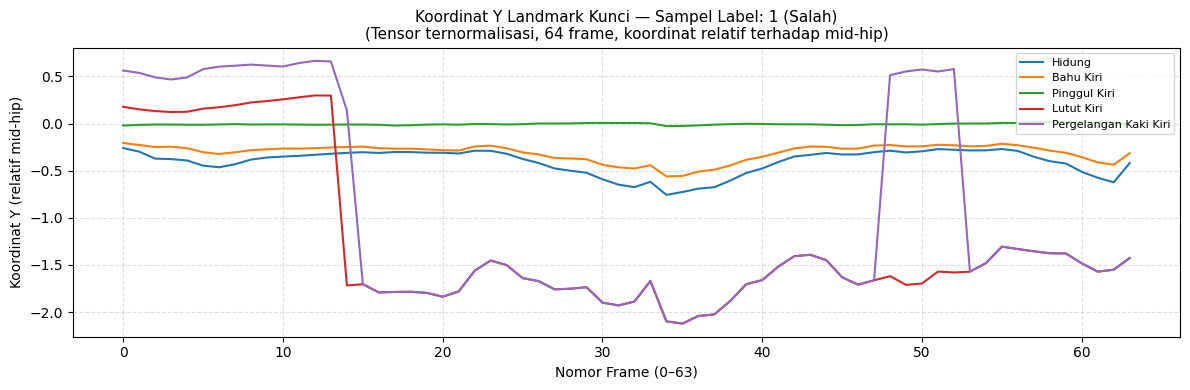

In [9]:
# ============================================================
# Visualisasikan koordinat Y landmark kunci dari satu sampel
# di dalam batch sebagai sanity check visual akhir.
# ============================================================
if not MANIFEST_PATH.exists() or len(dataset) == 0:
    print("[PERINGATAN] Dataset kosong. Lewati cell ini.")
else:
    # Ambil sampel pertama dari batch
    sample = batch_data[0].numpy() # (64, 33, 3)
    label = batch_labels[0].item()
    label_name = {0: "Benar", 1: "Salah"}.get(label, "?")
    
    LANDMARK_LABELS = {
        0:  "Hidung",
        11: "Bahu Kiri",
        23: "Pinggul Kiri",
        25: "Lutut Kiri",
        27: "Pergelangan Kaki Kiri",
    }

    fig, ax = plt.subplots(figsize=(12, 4))

    for lm_idx, lm_name in LANDMARK_LABELS.items():
        ax.plot(sample[:, lm_idx, 1], label=lm_name)

    ax.set_title(
        f"Koordinat Y Landmark Kunci — Sampel Label: {label} ({label_name})\n"
        f"(Tensor ternormalisasi, 64 frame, koordinat relatif terhadap mid-hip)",
        fontsize=11,
    )
    ax.set_xlabel("Nomor Frame (0–63)")
    ax.set_ylabel("Koordinat Y (relatif mid-hip)")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()